# Deep SVDD & JL Projection: Comprehensive Performance, Privacy, and Cost Analysis

This notebook provides a research-grade evaluation of the Johnson-Lindenstrauss (JL) projection for behavioral biometric authentication.

### Key Analytical Components:
1. **Predictive Performance**: Global ROC curves, AUC, and EER comparison.
2. **Behavioral Separation**: Density plots of distance scores for legitimate vs. imposter users.
3. **Computational Cost Breakdown**:
    - Matrix Generation (User-Unique Seed)
    - Transformation ($X \times P$)
    - Model Training Efficiency
4. **User Variability**: Boxplots and Scatter plots for per-user performance consistency.

In [39]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import os
import hashlib
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

DATA_PATH = r'../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/feature_importance_ranking/weighted_normalized_feature_extraction_V4_88_users.csv'

TARGET_DIM_JL = 64
HIDDEN_DIM = 64
LATENT_DIM = 32
LR = 0.001
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [40]:
def load_data(path):
    df = pd.read_csv(path)
    df = df.fillna(0)
    feature_cols = df.columns[2:]
    df[feature_cols] = df[feature_cols] * 10
    return df

df = load_data(DATA_PATH)
users = df['user_id'].unique()

In [41]:
class DeepSVDD(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32):
        super(DeepSVDD, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

def get_jl_projection(data, target_dim, user_id):
    t0 = time.perf_counter()
    n_features = data.shape[1]
    seed = int(hashlib.md5(str(user_id).encode()).hexdigest(), 16) % (2**32)
    rng = np.random.default_rng(seed=seed)
    projection_matrix = rng.standard_normal((n_features, target_dim)) / np.sqrt(target_dim)
    t1 = time.perf_counter()
    gen_time_ms = (t1 - t0) * 1000

    t2 = time.perf_counter()
    projected_data = data @ projection_matrix
    t3 = time.perf_counter()
    transform_time_ms = (t3 - t2) * 1000
    
    return projected_data, gen_time_ms, transform_time_ms

def init_center(model, train_loader, device):
    model.eval()
    outputs = []
    with torch.no_grad():
        for x in train_loader: outputs.append(model(x.to(device)))
    c = torch.cat(outputs).mean(dim=0)
    eps = 0.1
    c[(abs(c) < eps) & (c < 0)] = -eps
    c[(abs(c) < eps) & (c > 0)] = eps
    return c

def calculate_eer(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    idx = np.nanargmin(np.absolute((fpr - (1 - tpr))))
    return fpr[idx]

In [42]:
def train_and_evaluate_with_cost(X_train, X_test, y_test, input_dim):
    start_train = time.perf_counter()
    mem_bytes = X_train.memory_usage(deep=True).sum() + X_test.memory_usage(deep=True).sum()
    
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(DEVICE)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(DEVICE)
    
    model = DeepSVDD(input_dim, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)
    center = init_center(model, torch.utils.data.DataLoader(X_train_tensor, batch_size=8), DEVICE)
    
    model.train()
    for _ in range(EPOCHS):
        optimizer.zero_grad()
        loss = torch.sum((model(X_train_tensor) - center)**2, dim=1).mean()
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        distances = torch.sum((model(X_test_tensor) - center)**2, dim=1).cpu().numpy()
        train_dist = torch.sum((model(X_train_tensor) - center)**2, dim=1).cpu().numpy()
        threshold = np.max(train_dist)
        
    end_train = time.perf_counter()
    train_time_ms = (end_train - start_train) * 1000
    
    scores = -distances
    acc = accuracy_score(y_test, (distances <= threshold).astype(int))
    auc = roc_auc_score(y_test, scores)
    eer = calculate_eer(y_test, scores)
    
    return {'acc': acc, 'auc': auc, 'eer': eer, 'train_time_ms': train_time_ms, 'mem_bytes': mem_bytes, 'scores': scores}

In [43]:
results_no_jl = []
results_with_jl = []
all_y_true = []
all_scores_raw = []
all_scores_jl = []
feature_cols = df.columns[2:]

for user_id in users:
    user_data = df[df['user_id'] == user_id]
    legit = user_data[user_data['label'] == 1]
    imposter = user_data[user_data['label'] == 0]
    y_test = pd.concat([legit.iloc[8:10], imposter])['label'].values
    
    # --- No JL ---
    res_raw = train_and_evaluate_with_cost(legit.iloc[:8][feature_cols], pd.concat([legit.iloc[8:10], imposter])[feature_cols], y_test, len(feature_cols))
    results_no_jl.append({'user_id': user_id, 'gen_time_ms': 0, 'transform_time_ms': 0, **{k:v for k,v in res_raw.items() if k != 'scores'}})
    all_scores_raw.extend(res_raw['scores'])
    
    # --- With JL ---
    X_jl, gen_ms, trans_ms = get_jl_projection(user_data[feature_cols], TARGET_DIM_JL, user_id)
    res_jl = train_and_evaluate_with_cost(X_jl.iloc[:8], pd.concat([X_jl.iloc[8:10], X_jl.iloc[10:]]), y_test, TARGET_DIM_JL)
    results_with_jl.append({'user_id': user_id, 'gen_time_ms': gen_ms, 'transform_time_ms': trans_ms, **{k:v for k,v in res_jl.items() if k != 'scores'}})
    all_scores_jl.extend(res_jl['scores'])
    
    all_y_true.extend(y_test)
    if int(user_id) % 20 == 0: print(f"Processed user {user_id}/88")

df_raw = pd.DataFrame(results_no_jl)
df_jl = pd.DataFrame(results_with_jl)

Processed user 20/88
Processed user 40/88
Processed user 60/88
Processed user 80/88


,Metric,Raw,JL,Diff
0,ACC,0.833333,0.833333,0.000000
1,AUC,0.920455,0.911364,-0.009091
2,EER,0.127273,0.127273,0.000000
3,GEN_TIME_MS,0.000000,0.153369,0.153369
4,TRANSFORM_TIME_MS,0.000000,0.345444,0.345444
5,TRAIN_TIME_MS,117.872724,110.235928,-7.636795
6,MEM_BYTES,18024.000000,10504.000000,-7520.000000


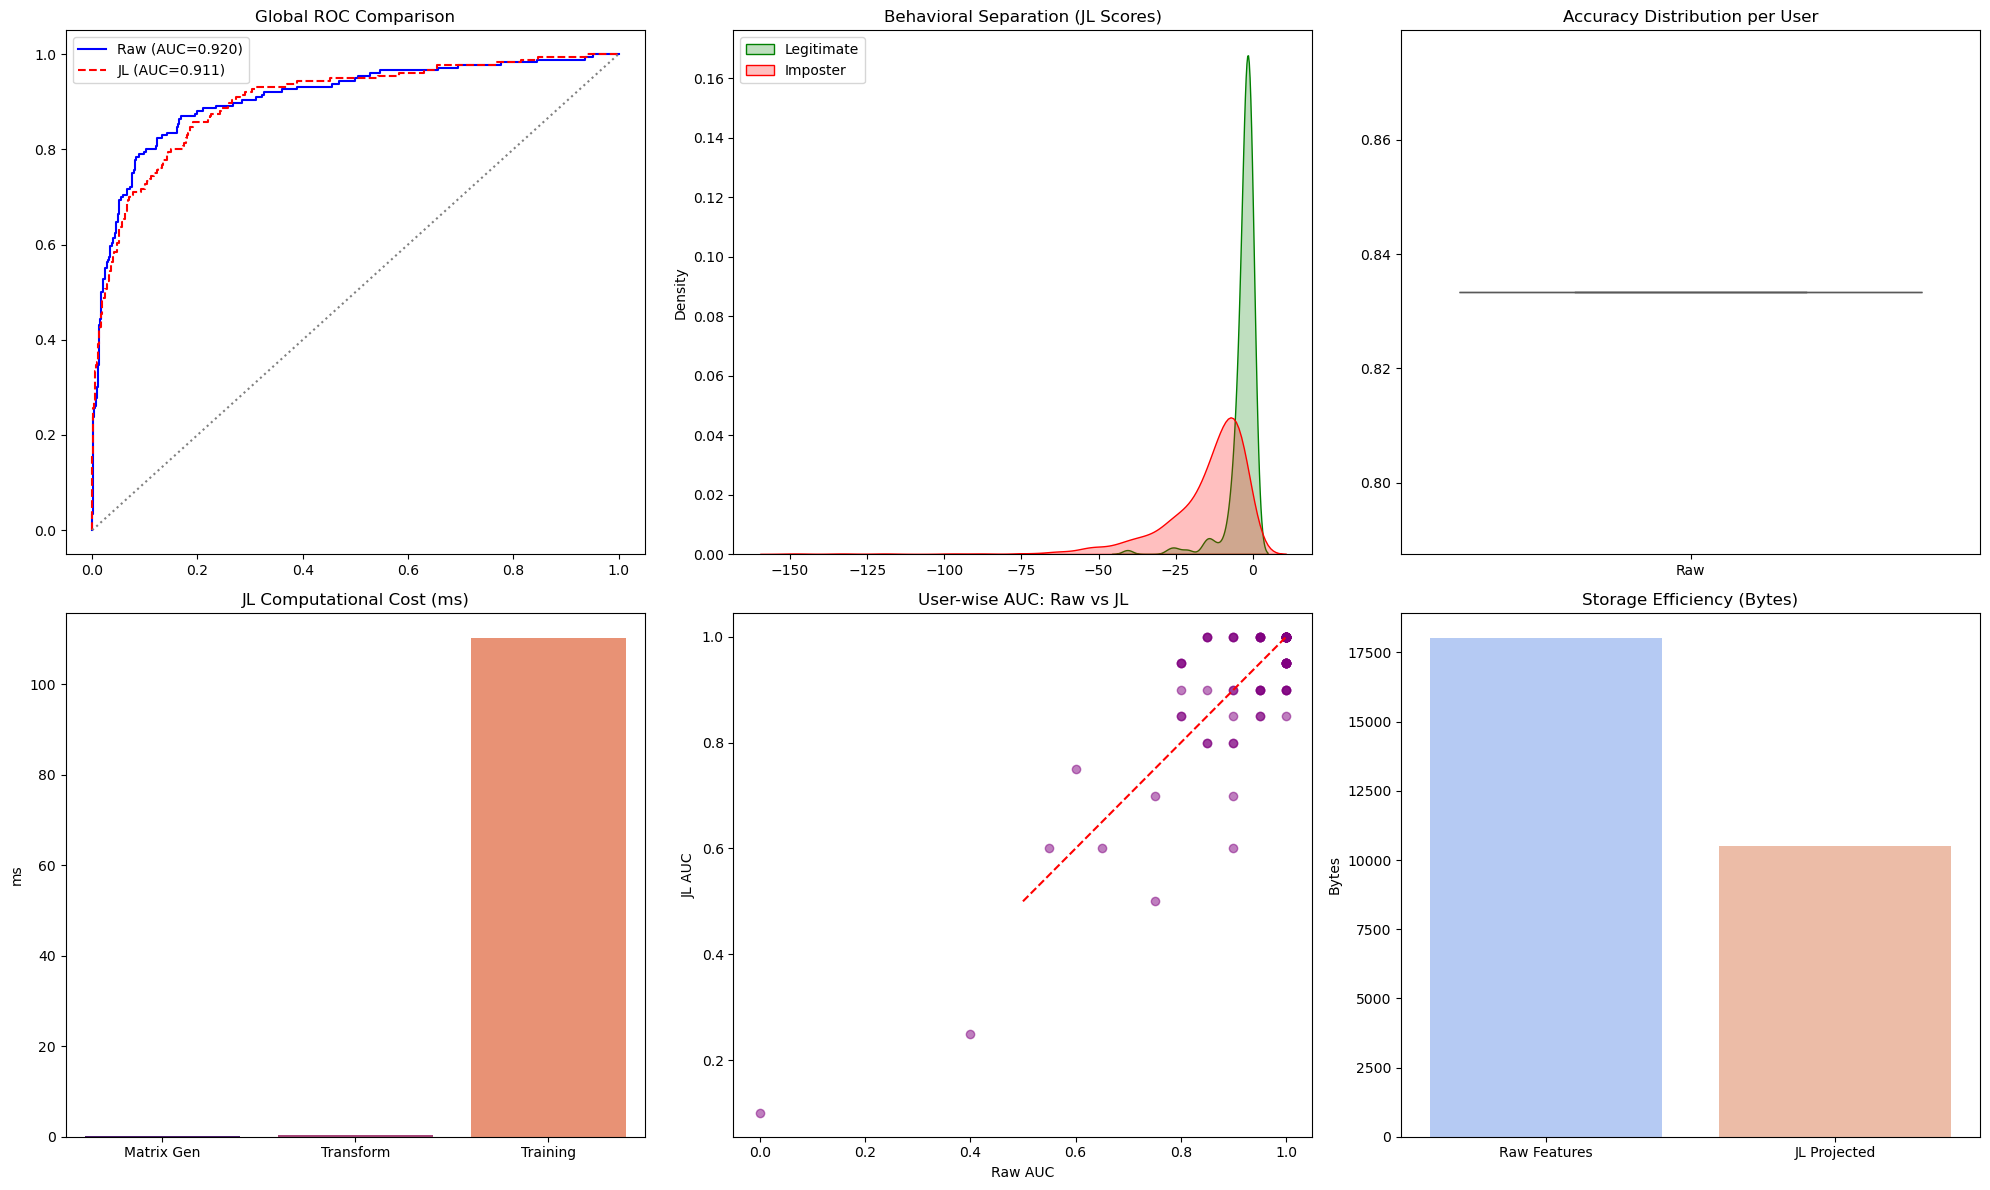

In [44]:
metrics = ['acc', 'auc', 'eer', 'gen_time_ms', 'transform_time_ms', 'train_time_ms', 'mem_bytes']
summary = []
for m in metrics:
    summary.append({'Metric': m.upper(), 'Raw': df_raw[m].mean(), 'JL': df_jl[m].mean(), 'Diff': df_jl[m].mean() - df_raw[m].mean()})
display(pd.DataFrame(summary))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. ROC Curve Comparison
fpr_r, tpr_r, _ = roc_curve(all_y_true, all_scores_raw)
fpr_j, tpr_j, _ = roc_curve(all_y_true, all_scores_jl)
axes[0,0].plot(fpr_r, tpr_r, label=f"Raw (AUC={df_raw['auc'].mean():.3f})", color='blue')
axes[0,0].plot(fpr_j, tpr_j, label=f"JL (AUC={df_jl['auc'].mean():.3f})", color='red', linestyle='--')
axes[0,0].plot([0,1],[0,1], color='gray', linestyle=':')
axes[0,0].set_title('Global ROC Comparison'); axes[0,0].legend()

# 2. Score Density (JL)
scores_jl = np.array(all_scores_jl); labels = np.array(all_y_true)
sns.kdeplot(scores_jl[labels==1], label='Legitimate', ax=axes[0,1], fill=True, color='green')
sns.kdeplot(scores_jl[labels==0], label='Imposter', ax=axes[0,1], fill=True, color='red')
axes[0,1].set_title('Behavioral Separation (JL Scores)'); axes[0,1].legend()

# 3. User Accuracy Variability
sns.boxplot(data=[df_raw['acc'], df_jl['acc']], ax=axes[0,2], palette='Set2')
axes[0,2].set_xticklabels(['Raw', 'JL']); axes[0,2].set_title('Accuracy Distribution per User')

# 4. Computational Time Overhead
overhead = [df_jl['gen_time_ms'].mean(), df_jl['transform_time_ms'].mean(), df_jl['train_time_ms'].mean()]
sns.barplot(x=['Matrix Gen', 'Transform', 'Training'], y=overhead, ax=axes[1,0], palette='magma')
axes[1,0].set_title('JL Computational Cost (ms)'); axes[1,0].set_ylabel('ms')

# 5. User-wise AUC Comparison
axes[1,1].scatter(df_raw['auc'], df_jl['auc'], alpha=0.5, color='purple')
axes[1,1].plot([0.5, 1], [0.5, 1], color='red', linestyle='--')
axes[1,1].set_title('User-wise AUC: Raw vs JL'); axes[1,1].set_xlabel('Raw AUC'); axes[1,1].set_ylabel('JL AUC')

# 6. Memory Consumption
sns.barplot(x=['Raw Features', 'JL Projected'], y=[df_raw['mem_bytes'].mean(), df_jl['mem_bytes'].mean()], ax=axes[1,2], palette='coolwarm')
axes[1,2].set_title('Storage Efficiency (Bytes)'); axes[1,2].set_ylabel('Bytes')

plt.tight_layout(); plt.show()